# LongT5 Email Thread Summarizer — Kaggle Training Notebook

Fine-tunes `google/long-t5-tglobal-base` on your **already-preprocessed** dataset.

Required columns:
- `thread_id`
- `email_body`
- `summary`

This notebook does **not** clean, relabel, or re-split the data.

In [1]:
%pip install -q evaluate rouge-score sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import inspect, json, gc, random, re, shutil

import numpy as np
import pandas as pd
import torch
import transformers
import evaluate

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

PyTorch: 2.10.0+cu128
Transformers: 5.0.0
CUDA available: True
GPU count: 1
GPU 0: Tesla T4


In [3]:
INPUT_ROOT = Path("/kaggle/input")

def find_dataset_root():
    matches = []

    for candidate in INPUT_ROOT.iterdir():
        if not candidate.is_dir():
            continue

        for csv_path in candidate.rglob("*.csv"):
            try:
                columns = set(
                    pd.read_csv(csv_path, nrows=0)
                    .columns.astype(str)
                    .str.strip()
                )

                required_columns = {
                    "thread_id",
                    "email_body",
                    "summary",
                }

                if required_columns.issubset(columns):
                    matches.append(candidate)
                    break
            except Exception:
                pass

    matches = list(dict.fromkeys(matches))

    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        f"Could not uniquely identify the dataset. Found: {matches}"
    )

DATASET_DIR = find_dataset_root()

WORK_DIR = Path("/kaggle/working/email-summarizer")
OUTPUT_DIR = WORK_DIR / "model_longt5_v1"
BEST_MODEL_DIR = OUTPUT_DIR / "best_model"

WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "google/long-t5-tglobal-base"

SOURCE_LENGTH = 1536
TARGET_LENGTH = 128
EPOCHS = 4

MAX_TRAIN_SAMPLES = None
EVAL_LIMIT = None

LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05
NUM_BEAMS = 4

print("Dataset:", DATASET_DIR)
print("Model:", MODEL_NAME)
print("Source length:", SOURCE_LENGTH)
print("Target length:", TARGET_LENGTH)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Output:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "No GPU detected"
)

Dataset: /kaggle/input/datasets
Model: google/long-t5-tglobal-base
Source length: 1536
Target length: 128
Epochs: 4
Learning rate: 2e-05
Output: /kaggle/working/email-summarizer/model_longt5_v1
CUDA available: True
GPU: Tesla T4


In [4]:
REQUIRED_COLUMNS = {"thread_id", "email_body", "summary"}
compatible_csvs = []

for path in sorted(DATASET_DIR.rglob("*.csv")):
    try:
        cols = set(
            pd.read_csv(path, nrows=0)
            .columns.astype(str)
            .str.strip()
        )
        if REQUIRED_COLUMNS.issubset(cols):
            compatible_csvs.append(path)
    except Exception:
        pass

print(f"Compatible CSV files found: {len(compatible_csvs)}")
for p in compatible_csvs:
    print(p)

if len(compatible_csvs) < 3:
    raise FileNotFoundError(
        "Expected train/validation/test CSV files with "
        "thread_id, email_body, summary columns."
    )

Compatible CSV files found: 4
/kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/email_thread_summary_all.csv
/kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/test/email_thread_summary_test.csv
/kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/train/email_thread_summary_train.csv
/kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/val/email_thread_summary_val.csv


In [5]:
def find_split_csv(split):
    candidates = []

    for path in compatible_csvs:
        name = path.name.lower()

        if split == "train":
            if "train" in name and "history" not in name:
                candidates.append(path)

        elif split == "validation":
            if (
                "validation" in name
                or "valid" in name
                or "val" in name
                or "dev" in name
            ):
                candidates.append(path)

        elif split == "test":
            if "test" in name:
                candidates.append(path)

    if not candidates:
        raise FileNotFoundError(
            f"No processed {split} CSV found under {DATASET_DIR}"
        )

    candidates = sorted(
        candidates,
        key=lambda p: (len(p.parts), len(p.name), str(p))
    )

    if len(candidates) > 1:
        print(f"Multiple {split} candidates:")
        for c in candidates:
            print(" ", c)
        print("Using:", candidates[0])

    return candidates[0]

TRAIN_FILE = find_split_csv("train")
VAL_FILE = find_split_csv("validation")
TEST_FILE = find_split_csv("test")

print("Train      :", TRAIN_FILE)
print("Validation :", VAL_FILE)
print("Test       :", TEST_FILE)

Train      : /kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/train/email_thread_summary_train.csv
Validation : /kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/val/email_thread_summary_val.csv
Test       : /kaggle/input/datasets/prishabhkumar/email-thread-summarization-dataset/test/email_thread_summary_test.csv


In [6]:
train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

train_df.columns = train_df.columns.astype(str).str.strip()
val_df.columns = val_df.columns.astype(str).str.strip()
test_df.columns = test_df.columns.astype(str).str.strip()

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("Columns    :", train_df.columns.tolist())

for split_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    missing = REQUIRED_COLUMNS - set(df.columns)
    assert not missing, f"{split_name} missing: {missing}"

print("Required columns verified.")

Train      : 2870
Validation : 615
Test       : 616
Columns    : ['thread_id', 'email_body', 'summary']
Required columns verified.


In [7]:
for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print("\n", split_name)
    print(df[["thread_id", "email_body", "summary"]].isna().sum())

assert train_df["email_body"].notna().all()
assert train_df["summary"].notna().all()
assert val_df["email_body"].notna().all()
assert val_df["summary"].notna().all()
assert test_df["email_body"].notna().all()
assert test_df["summary"].notna().all()

sample = train_df.iloc[0]
print("\nTHREAD ID:", sample["thread_id"])
print("\nEMAIL BODY:\n", str(sample["email_body"])[:1500])
print("\nREFERENCE SUMMARY:\n", sample["summary"])


 Train
thread_id     0
email_body    0
summary       0
dtype: int64

 Validation
thread_id     0
email_body    0
summary       0
dtype: int64

 Test
thread_id     0
email_body    0
summary       0
dtype: int64

THREAD ID: 3054

EMAIL BODY:
 Good thing you mentioned that.  I can see that the attachment on this email is different than the one I sent before.  I will be sending out another email this afternoon just introducing the "Enron" team to each other.  

 -----Original Message-----
From: 	jeffsmirin@txu.com@ENRON  
Sent:	Thursday, April 04, 2002 9:11 AM
To:	Germany, Chris
Subject:	Ponderosa Pines Energy

(See attached file: Tenaska IV Est Imbalance0302.xls)
 - Tenaska IV Est Imbalance0302.xls

--- EMAIL MESSAGE ---

Imbalance numbers for April.

 -----Original Message-----
From: 	jeffsmirin@txu.com@ENRON  
Sent:	Thursday, April 11, 2002 3:50 PM
To:	Germany, Chris; Denetsosie, Troy; Kelly, Katherine L.; Dinari, Sabra L.
Subject:	Ponderosa Pines Energy

(See attached file: Tenaska IV

In [8]:
if MAX_TRAIN_SAMPLES is not None:
    train_df = train_df.iloc[:MAX_TRAIN_SAMPLES].copy()

if EVAL_LIMIT is not None:
    val_df = val_df.iloc[:EVAL_LIMIT].copy()
    test_df = test_df.iloc[:EVAL_LIMIT].copy()

print("Rows used")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Rows used
Train      : 2870
Validation : 615
Test       : 616


In [9]:
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["thread_id", "email_body", "summary"]],
        preserve_index=False,
    ),
    "validation": Dataset.from_pandas(
        val_df[["thread_id", "email_body", "summary"]],
        preserve_index=False,
    ),
    "test": Dataset.from_pandas(
        test_df[["thread_id", "email_body", "summary"]],
        preserve_index=False,
    ),
})

print(hf_dataset)

DatasetDict({
    train: Dataset({
        features: ['thread_id', 'email_body', 'summary'],
        num_rows: 2870
    })
    validation: Dataset({
        features: ['thread_id', 'email_body', 'summary'],
        num_rows: 615
    })
    test: Dataset({
        features: ['thread_id', 'email_body', 'summary'],
        num_rows: 616
    })
})


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_size = min(500, len(hf_dataset["train"]))
length_sample = hf_dataset["train"].select(range(sample_size))

def measure_length(example):
    ids = tokenizer(
        str(example["email_body"]),
        truncation=False,
        add_special_tokens=True,
    )["input_ids"]
    return {"source_token_length": len(ids)}

length_sample = length_sample.map(
    measure_length,
    desc="Measuring source lengths"
)

lengths = np.asarray(length_sample["source_token_length"])

print("Samples checked :", len(lengths))
print("Mean tokens     :", round(float(lengths.mean()), 2))
print("Median tokens   :", round(float(np.median(lengths)), 2))
print("90th percentile :", round(float(np.percentile(lengths, 90)), 2))
print("95th percentile :", round(float(np.percentile(lengths, 95)), 2))
print("Maximum         :", int(lengths.max()))
print("% over 512     :", round(float((lengths > 512).mean() * 100), 2), "%")
print("% over 2048    :", round(float((lengths > 2048).mean() * 100), 2), "%")

config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Measuring source lengths:   0%|          | 0/500 [00:00<?, ? examples/s]

Samples checked : 500
Mean tokens     : 2502.75
Median tokens   : 1567.5
90th percentile : 5010.7
95th percentile : 7637.85
Maximum         : 41966
% over 512     : 87.6 %
% over 2048    : 38.0 %


In [11]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# LongT5 does not require the T5 "summarize:" task prefix.
model.gradient_checkpointing_enable()
model.config.use_cache = False

model.generation_config.num_beams = NUM_BEAMS
model.generation_config.max_length = TARGET_LENGTH
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.repetition_penalty = 1.05
model.generation_config.early_stopping = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total parameters    : {total_params / 1e6:.2f} M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f} M")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/297 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Total parameters    : 296.94 M
Trainable parameters: 296.94 M


In [12]:
def preprocess_batch(batch):
    sources = [str(x) for x in batch["email_body"]]
    targets = [str(x) for x in batch["summary"]]

    model_inputs = tokenizer(
        sources,
        max_length=SOURCE_LENGTH,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=TARGET_LENGTH,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = hf_dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=hf_dataset["train"].column_names,
    desc="Tokenizing"
)

print(tokenized_dataset)

ex = tokenized_dataset["train"][0]
print("Input tokens :", len(ex["input_ids"]))
print("Target tokens:", len(ex["labels"]))

Tokenizing:   0%|          | 0/2870 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/615 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/616 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2870
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 615
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 616
    })
})
Input tokens : 1536
Target tokens: 122


In [13]:
rouge = evaluate.load("rouge")

def sentence_newline_format(text):
    text = str(text).strip()
    if not text:
        return text
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return "\n".join(
        s.strip() for s in sentences if s.strip()
    )

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    decoded_preds = [
        sentence_newline_format(x.strip())
        for x in decoded_preds
    ]
    decoded_labels = [
        sentence_newline_format(x.strip())
        for x in decoded_labels
    ]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    result = {
        key: round(float(value) * 100, 4)
        for key, value in result.items()
    }

    pred_lens = [
        np.count_nonzero(pred != tokenizer.pad_token_id)
        for pred in predictions
    ]
    result["gen_len"] = round(
        float(np.mean(pred_lens)), 2
    )

    return result

print("ROUGE ready.")

ROUGE ready.


In [14]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

print("Data collator ready.")

Data collator ready.


In [15]:
use_bf16 = False
use_fp16 = False

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,

    warmup_steps=72,
    lr_scheduler_type="linear",
    optim="adamw_torch",

    predict_with_generate=True,
    generation_max_length=TARGET_LENGTH,
    generation_num_beams=NUM_BEAMS,

    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="rougeLsum",
    greater_is_better=True,

    gradient_checkpointing=True,
    max_grad_norm=1.0,

    fp16=use_fp16,
    bf16=use_bf16,

    eval_accumulation_steps=4,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

params = inspect.signature(
    Seq2SeqTrainingArguments.__init__
).parameters

if "eval_strategy" in params:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = Seq2SeqTrainingArguments(
    **training_kwargs
)

effective_batch = (
    TRAIN_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
    * max(1, torch.cuda.device_count())
)

print(
    "Precision:",
    "bf16" if use_bf16
    else ("fp16" if use_fp16 else "fp32")
)
print("Effective batch:", effective_batch)
print("Best-model metric: rougeLsum")

Precision: fp32
Effective batch: 8
Best-model metric: rougeLsum


In [16]:
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ],
)

trainer_params = inspect.signature(
    Seq2SeqTrainer.__init__
).parameters

if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Seq2SeqTrainer(**trainer_kwargs)

print("Trainer ready.")

Trainer ready.


In [17]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

train_result = trainer.train()

print("\nTraining complete.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation ROUGE-Lsum:", trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,17.180624,1.574518,36.077000,15.623300,23.929800,32.891500,70.020000
2,15.296982,1.498509,39.654200,17.838500,26.376500,36.481500,72.450000
3,15.488621,1.469833,41.228700,18.655900,27.134500,38.002700,76.710000
4,15.153923,1.461442,41.717000,18.842800,27.547600,38.532000,77.480000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete.
Best checkpoint: /kaggle/working/email-summarizer/model_longt5_v1/checkpoint-1436
Best validation ROUGE-Lsum: 38.532


In [18]:
BEST_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

trainer.save_model(str(BEST_MODEL_DIR))
tokenizer.save_pretrained(str(BEST_MODEL_DIR))

trainer.model.config.use_cache = True
trainer.model.generation_config.save_pretrained(
    str(BEST_MODEL_DIR)
)

print("Best model saved to:")
print(BEST_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to:
/kaggle/working/email-summarizer/model_longt5_v1/best_model


In [19]:
validation_results = trainer.evaluate(
    eval_dataset=tokenized_dataset["validation"],
    metric_key_prefix="validation"
)

test_results = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test"
)

print("\nVALIDATION RESULTS")
print("=" * 60)
for key, value in validation_results.items():
    print(f"{key:35s}: {value}")

print("\nTEST RESULTS")
print("=" * 60)
for key, value in test_results.items():
    print(f"{key:35s}: {value}")

early stopping required metric_for_best_model, but did not find eval_rougeLsum so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_rougeLsum so early stopping is disabled



VALIDATION RESULTS
validation_loss                    : 1.4614421129226685
validation_rouge1                  : 41.717
validation_rouge2                  : 18.8428
validation_rougeL                  : 27.5476
validation_rougeLsum               : 38.532
validation_gen_len                 : 77.48
validation_runtime                 : 1530.8344
validation_samples_per_second      : 0.402
validation_steps_per_second        : 0.402
epoch                              : 4.0

TEST RESULTS
test_loss                          : 1.4783629179000854
test_rouge1                        : 42.2951
test_rouge2                        : 19.3685
test_rougeL                        : 28.2345
test_rougeLsum                     : 39.157
test_gen_len                       : 77.27
test_runtime                       : 1533.5348
test_samples_per_second            : 0.402
test_steps_per_second              : 0.402
epoch                              : 4.0


In [20]:
inference_model = trainer.model
inference_model.config.use_cache = True

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

inference_model.to(device)
inference_model.eval()

def summarize_email(email_text):
    inputs = tokenizer(
        str(email_text),
        return_tensors="pt",
        max_length=SOURCE_LENGTH,
        truncation=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        output_ids = inference_model.generate(
            **inputs,
            num_beams=NUM_BEAMS,
            max_new_tokens=TARGET_LENGTH,
            min_new_tokens=10,
            no_repeat_ngram_size=3,
            repetition_penalty=1.05,
            early_stopping=True
        )

    return tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

for i in range(min(5, len(test_df))):
    row = test_df.iloc[i]
    prediction = summarize_email(
        row["email_body"]
    )

    print("\n" + "=" * 100)
    print(f"TEST EXAMPLE {i + 1}")
    print("=" * 100)
    print("\nREFERENCE:")
    print(row["summary"])
    print("\nGENERATED:")
    print(prediction)


TEST EXAMPLE 1

REFERENCE:
There is confusion regarding the Nicor Gas Company contracts and their classification as a hub or storage facility. The contracts have existed since 1995 and are currently causing issues with receivables and payables. The team is working on setting up new contracts and deal tickets to address the outstanding issues. They are also exploring the possibility of using CPR exchange tickets instead of the current EDI process. Assistance is requested to clear the outstanding balances.

GENERATED:
The email thread discusses the Nicor Hub contracts, which are not being booked correctly and need to be cleared through Unify. Marlo James asks for assistance in setting up storage contracts for the deals that address the Balancing/Wheeling/ and Loan volumes that ENA is charged by the Hub every month. He also mentions that Sylvia Campos has stated that those tickets were not possible to put in because Nicor is an Hub not a storage facility.

TEST EXAMPLE 2

REFERENCE:
Kay 

In [21]:
history_df = pd.DataFrame(
    trainer.state.log_history
)

history_file = (
    WORK_DIR / "training_history.csv"
)
history_df.to_csv(
    history_file,
    index=False
)

results = {
    "model": MODEL_NAME,
    "source_length": SOURCE_LENGTH,
    "target_length": TARGET_LENGTH,
    "epochs_configured": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_rougeLsum": trainer.state.best_metric,
    "validation": {
        k: float(v)
        if isinstance(v, (int, float, np.number))
        else str(v)
        for k, v in validation_results.items()
    },
    "test": {
        k: float(v)
        if isinstance(v, (int, float, np.number))
        else str(v)
        for k, v in test_results.items()
    },
}

metrics_file = (
    WORK_DIR / "final_metrics.json"
)

with open(metrics_file, "w") as f:
    json.dump(
        results,
        f,
        indent=2
    )

print("Training history:", history_file)
print("Final metrics:", metrics_file)

Training history: /kaggle/working/email-summarizer/training_history.csv
Final metrics: /kaggle/working/email-summarizer/final_metrics.json


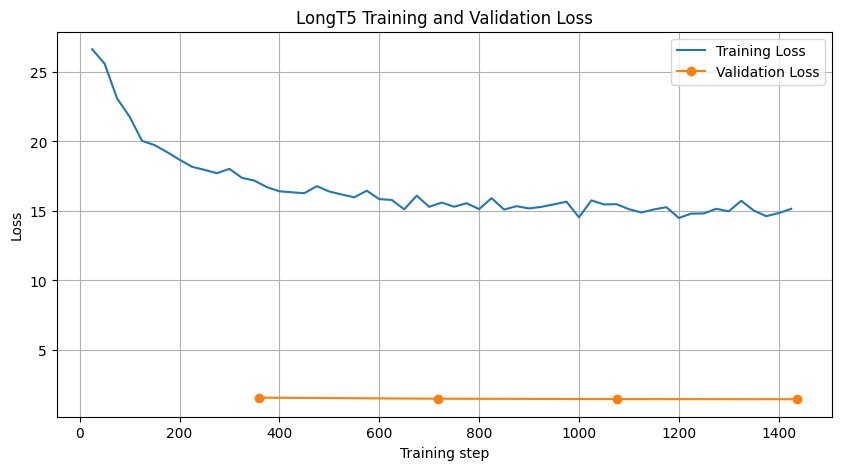

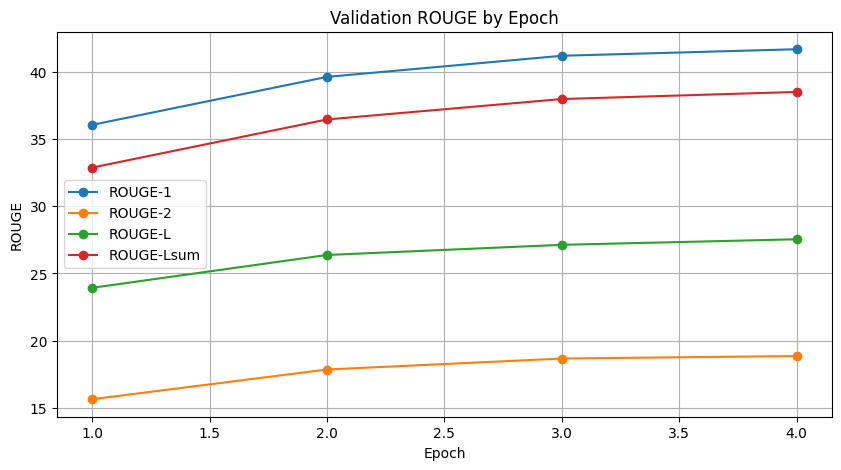

In [22]:
import matplotlib.pyplot as plt

history = pd.DataFrame(
    trainer.state.log_history
)

if "loss" in history.columns:
    train_logs = history[
        history["loss"].notna()
    ].copy()
else:
    train_logs = pd.DataFrame()

if "eval_loss" in history.columns:
    eval_logs = history[
        history["eval_loss"].notna()
    ].copy()
else:
    eval_logs = pd.DataFrame()

plt.figure(figsize=(10, 5))

if len(train_logs):
    plt.plot(
        train_logs["step"],
        train_logs["loss"],
        label="Training Loss"
    )

if len(eval_logs):
    plt.plot(
        eval_logs["step"],
        eval_logs["eval_loss"],
        marker="o",
        label="Validation Loss"
    )

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("LongT5 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

if "eval_rouge1" in history.columns:
    rouge_logs = history[
        history["eval_rouge1"].notna()
    ].copy()

    if len(rouge_logs):
        plt.figure(figsize=(10, 5))
        plt.plot(
            rouge_logs["epoch"],
            rouge_logs["eval_rouge1"],
            marker="o",
            label="ROUGE-1"
        )
        plt.plot(
            rouge_logs["epoch"],
            rouge_logs["eval_rouge2"],
            marker="o",
            label="ROUGE-2"
        )
        plt.plot(
            rouge_logs["epoch"],
            rouge_logs["eval_rougeL"],
            marker="o",
            label="ROUGE-L"
        )
        plt.plot(
            rouge_logs["epoch"],
            rouge_logs["eval_rougeLsum"],
            marker="o",
            label="ROUGE-Lsum"
        )

        plt.xlabel("Epoch")
        plt.ylabel("ROUGE")
        plt.title("Validation ROUGE by Epoch")
        plt.legend()
        plt.grid(True)
        plt.show()

In [23]:
zip_path = shutil.make_archive(
    str(
        WORK_DIR
        / "email_longt5_best_model"
    ),
    "zip",
    root_dir=str(BEST_MODEL_DIR)
)

print("Model archive:")
print(zip_path)

print("\nFiles created:")
for p in sorted(WORK_DIR.rglob("*")):
    if p.is_file():
        print(p)

Model archive:
/kaggle/working/email-summarizer/email_longt5_best_model.zip

Files created:
/kaggle/working/email-summarizer/email_longt5_best_model.zip
/kaggle/working/email-summarizer/final_metrics.json
/kaggle/working/email-summarizer/model_longt5_v1/best_model/config.json
/kaggle/working/email-summarizer/model_longt5_v1/best_model/generation_config.json
/kaggle/working/email-summarizer/model_longt5_v1/best_model/model.safetensors
/kaggle/working/email-summarizer/model_longt5_v1/best_model/tokenizer.json
/kaggle/working/email-summarizer/model_longt5_v1/best_model/tokenizer_config.json
/kaggle/working/email-summarizer/model_longt5_v1/best_model/training_args.bin
/kaggle/working/email-summarizer/model_longt5_v1/checkpoint-1077/config.json
/kaggle/working/email-summarizer/model_longt5_v1/checkpoint-1077/generation_config.json
/kaggle/working/email-summarizer/model_longt5_v1/checkpoint-1077/model.safetensors
/kaggle/working/email-summarizer/model_longt5_v1/checkpoint-1077/optimizer.pt
/

In [24]:
from pathlib import Path

matches = list(Path("/kaggle").rglob("email_longt5_best_model.zip"))

print(matches)

[PosixPath('/kaggle/working/email-summarizer/email_longt5_best_model.zip')]


## Result interpretation

The original EmailSum repository reports, for **T5-base on the long-summary one-reference task**:

- ROUGE-1: **43.87**
- ROUGE-2: **14.10**
- ROUGE-L: **30.50**
- ROUGE-Lsum: **39.91**

Use these as benchmark context only. Exact comparison requires the same dataset split, preprocessing, and reference setup.